### Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

### Data Loading

In [2]:
df = pd.read_csv('C:/Users/Pratik/DS/house_prediction_uncertainty/data/processed/house_prices_features_v1.csv')

### Data Splitting & Model Training


In [3]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['SalePrice', 'SalePrice_log'])
y = df['SalePrice_log']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
# Using linear regression for baseline model 
from sklearn.linear_model import LinearRegression
model_LR = LinearRegression()
model_LR.fit(X_train, y_train)
y_pred = model_LR.predict(X_test)

In [5]:
# Inverse transform the log predictions to get actual sale prices
y_pred_actual = np.expm1(y_pred)
y_test_actual = np.expm1(y_test)

### Quantile Regression

Quantile regression is used to estimate conditional quantiles of the target variable, providing insight into the uncertainty of predictions beyond the mean. We use XGBoost to perform quantile regression & estimate prediction interval for house prices.
Specially, we model three conditional quantiles:
- q10: 10th percentile, providing a lower-bound estimate of house prices
- q50: 50th percentile, representing the median or central tendency
- q90: 90th percentile, proving an upper-bound estimate

Each model is trained on same features as baseline models. Predictions are generated in log-transformed space & then inversed to original scale.
These quantiles allow us to construct prediction intervals, offering a ranger within which true house price is likely to fall, thereby quantifying prediction uncertainty

In [6]:
# XBoost Regressor with Quantile Regression
# Model for 10th percentile (quantile alpha = 0.1)
model_XGB_q10 = xgb.XGBRegressor(
    objective='reg:quantileerror',
    quantile_alpha=0.1,
    n_estimators=100,
    learning_rate=0.1, 
    max_depth=6, 
    random_state=42
    )
model_XGB_q10.fit(X_train, y_train)
y_xgb_q10_pred = model_XGB_q10.predict(X_test)
y_xgb_q10_actual = np.expm1(y_xgb_q10_pred)

In [7]:
# Model for Median (quantile alpha = 0.5)
model_XGB_q50 = xgb.XGBRegressor(
    objective='reg:quantileerror',
    quantile_alpha=0.5,
    n_estimators=100,
    learning_rate=0.1, 
    max_depth=6, 
    random_state=42
    )
model_XGB_q50.fit(X_train, y_train)
y_xgb_q50_pred = model_XGB_q50.predict(X_test)
y_xgb_q50_actual = np.expm1(y_xgb_q50_pred)

In [8]:
# Model for 90th percentile (quantile alpha = 0.9)
model_XGB_q90 = xgb.XGBRegressor(
    objective='reg:quantileerror',
    quantile_alpha=0.9,
    n_estimators=100,
    learning_rate=0.1, 
    max_depth=6, 
    random_state=42
    )
model_XGB_q90.fit(X_train, y_train)
y_xgb_q90_pred = model_XGB_q90.predict(X_test)
y_xgb_q90_actual = np.expm1(y_xgb_q90_pred)

### Prediction Intervals
Using the 10th & 90th percentile predictions, we constuct prediction intervals for each house price.
These intervals provide a ranger within which true price is likely to die.

In [9]:
# Prediction Intervals
Lower_PI = y_xgb_q10_actual
Upper_PI = y_xgb_q90_actual

We evaluated the intervals using:
- Coverage: The proportion of test set pieces that fall within prediction interval.

In [10]:
coverage = np.mean((y_test_actual >= Lower_PI) & (y_test_actual <= Upper_PI))
print(f'Prediction Interval Coverage: {coverage * 100:.2f}%')
# how often the true price lies within the predicted interval.

Prediction Interval Coverage: 59.59%


- Coverage by Price bin: the intervals are assessed across different house price segments (Low, Mid, High, Luxury) to ensure reliability across price spectrum.

In [11]:
bins = pd.qcut(y_test_actual, q=4, labels=["Low", "Mid", "High", "Luxury"])
coverage_by_bin = pd.DataFrame({
    "price_bin": bins,
    "covered": (y_test_actual >= Lower_PI) & (y_test_actual <= Upper_PI)
}).groupby("price_bin")["covered"].mean()

print(coverage_by_bin)

price_bin
Low       0.586667
Mid       0.718310
High      0.575342
Luxury    0.506849
Name: covered, dtype: float64


C:\Users\Pratik\AppData\Local\Temp\ipykernel_1592\3673907544.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  }).groupby("price_bin")["covered"].mean()


- Interval Width: the average width of prediction intervals, indicating the uncertainty magnitude in the predictions.

In [12]:
interval_width = Upper_PI - Lower_PI
print(f'Average Prediction Interval Width: {np.mean(interval_width):.2f}')

Average Prediction Interval Width: 38108.57


### Scatter Plot Uncertainty vs Price Level

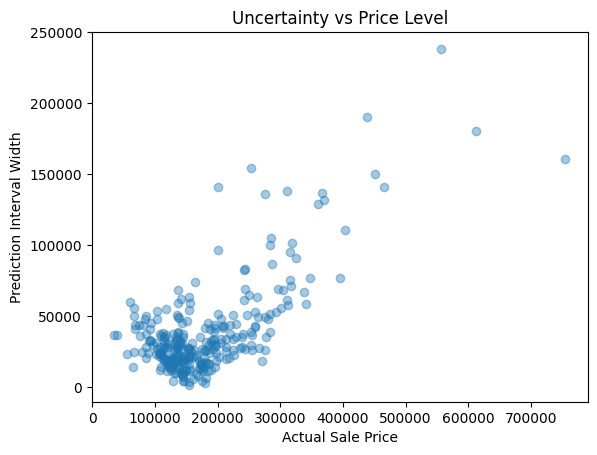

In [13]:
plt.scatter(y_test_actual, Upper_PI - Lower_PI, alpha=0.4)
plt.xlabel("Actual Sale Price")
plt.ylabel("Prediction Interval Width")
plt.title("Uncertainty vs Price Level")
plt.savefig('C:/Users/Pratik/DS/house_prediction_uncertainty/reports/figures/Uncertainty_vs_Price_level.png')
plt.show()

Uncertainty tends to be smaller for lower-priced houses. The quantile regression intervals are not perfectly calibrated, and further calibration (e.g. conformal prediction) is planned for  future work

### Prediction Summary & Risk Assessment
We consolidate the model predictions & uncertainty estimates into a singular summary table.
- Actual Price: True house prices
- PredictedPrice: Median predictions (q50) from XGBoost
- Lower_PI/Upper_PI: 10th & 90th percentile predictions forming prediction interval
- Interval_Width: Difference between upper & lower bounds, indicating absolute uncertainty
- RiskBand: Categorizes properties based on interval width into Low Risk, Medium Risk & High Risk.
- Relative_Uncertainty: Interval width expressed as a percentage of the predicted price, providing a normalized measure of prediction uncertainty.

In [14]:
df_results = pd.DataFrame({
    'Actual_Price': y_test_actual,
    'PredictedPrice': y_xgb_q50_actual,
    'Lower_PI': Lower_PI,
    'Upper_PI': Upper_PI,
    'Interval_Width': interval_width
})

df_results['RiskBand'] = pd.qcut(df_results['Interval_Width'], q=[0 , 0.33, 0.66, 1.0], labels=['Low Risk', 'Medium Risk', 'High Risk'])
df_results['Relative_Uncertainty'] = df_results['Interval_Width'] / df_results['PredictedPrice'] * 100
df_results.to_csv('C:/Users/Pratik/DS/house_prediction_uncertainty/reports/summary _tables/results.csv')
df_results.head()

,Actual_Price,PredictedPrice,Lower_PI,Upper_PI,Interval_Width,RiskBand,Relative_Uncertainty
892,154500.0,143706.734375,129828.867188,151536.859375,21707.992188,Low Risk,15.105759
1105,325000.0,336579.937500,247831.265625,338808.218750,90976.953125,High Risk,27.029821
413,115000.0,114903.257812,107248.929688,136088.343750,28839.414062,Medium Risk,25.098866
522,159000.0,159484.109375,140963.343750,172518.359375,31555.015625,Medium Risk,19.785681
1036,315500.0,313190.062500,248286.890625,323569.062500,75282.171875,High Risk,24.037216


### Comparison of Homes by Predicted Price & Uncertainty

In [17]:
# Find homes with similar predicted prices but different uncertainty levels
df_results['PriceBucket'] = pd.qcut(df_results['PredictedPrice'], q=5)

comparison = df_results.sort_values('Interval_Width').groupby('PriceBucket', observed=False).head(2)
comparison[['PredictedPrice','Lower_PI','Upper_PI', 'Interval_Width', 'RiskBand']]
comparison.to_csv('C:/Users/Pratik/DS/house_prediction_uncertainty/reports/summary _tables/comparison.csv')

comparison

,Actual_Price,PredictedPrice,Lower_PI,Upper_PI,Interval_Width,RiskBand,Relative_Uncertainty,PriceBucket
151,155000.0,140445.640625,139160.375000,140833.265625,1672.890625,Low Risk,1.191130,"(121057.109, 140768.2]"
269,180000.0,176401.140625,164408.046875,167317.375000,2909.328125,Low Risk,1.649268,"(140768.2, 176439.503]"
25,153900.0,167051.109375,164654.234375,168641.562500,3987.328125,Low Risk,2.386891,"(140768.2, 176439.503]"
124,175000.0,187625.953125,191316.156250,195576.687500,4260.531250,Low Risk,2.270758,"(176439.503, 218605.391]"
23,129000.0,122820.195312,126149.468750,130937.382812,4787.914062,Low Risk,3.898312,"(121057.109, 140768.2]"
28,181000.0,179016.468750,174936.093750,181660.875000,6724.781250,Low Risk,3.756515,"(176439.503, 218605.391]"
148,133900.0,119439.851562,121547.406250,131763.765625,10216.359375,Low Risk,8.553560,"(58736.183000000005, 121057.109]"
70,118858.0,118945.265625,117558.828125,128898.156250,11339.328125,Low Risk,9.533232,"(58736.183000000005, 121057.109]"
186,271000.0,289580.468750,245708.046875,264033.031250,18324.984375,Low Risk,6.328115,"(218605.391, 460030.438]"
34,255000.0,256646.453125,239033.500000,265209.062500,26175.562500,Medium Risk,10.199075,"(218605.391, 460030.438]"


Properties with similar predicted prices are compared by their prediction interval widths to highlight differences in uncertainty and identify higher-risk cases for further review.

### Prediction Intervals for Sample Homes

Dots show the predicted prices q50 , and error bars represent 10th-90th percentile prediction intervals for 50 random sampled homes, illustrating the uncertainty around each predicted price.

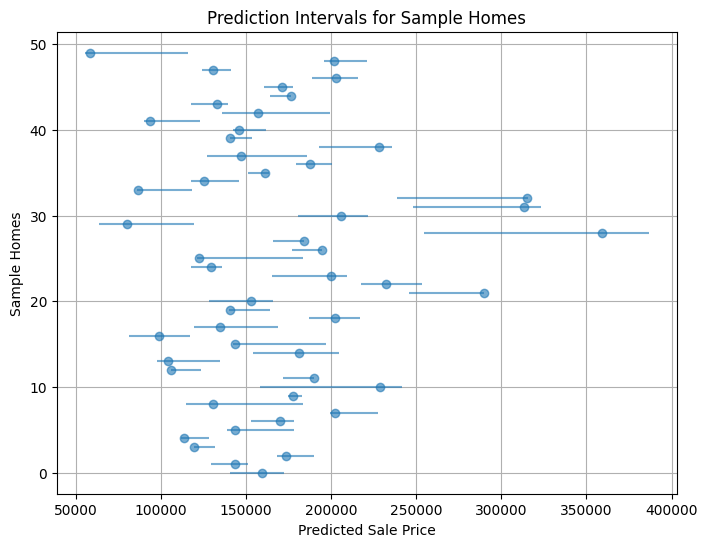

In [16]:
df_results = df_results.reset_index(drop=True)

sample_idx = np.random.choice(len(df_results), 50, replace=False)

left_error = np.maximum(df_results["PredictedPrice"] - df_results["Lower_PI"], 0)

right_error = np.maximum(df_results["Upper_PI"] - df_results["PredictedPrice"], 0)


plt.figure(figsize=(8, 6))
plt.errorbar(
    df_results.iloc[sample_idx]["PredictedPrice"],
    range(len(sample_idx)),
    xerr=[left_error.iloc[sample_idx], right_error.iloc[sample_idx]    ],
    fmt='o',
    alpha=0.6
)

plt.xlabel("Predicted Sale Price")
plt.ylabel("Sample Homes")
plt.title("Prediction Intervals for Sample Homes")
plt.grid(True)
plt.savefig('C:/Users/Pratik/DS/house_prediction_uncertainty/reports/figures/Prediction_intervals_for_sample_homes.png')
plt.show()


### Example Predictions with Uncertainty

For selected homes, the model outputs a predicted price range rather than a single value.
Wider intervals indicate higher uncertainty and potential risk

In [21]:
example_preds = df_results.sample(5, random_state=42)

example_preds[[
    "PredictedPrice",
    "Lower_PI",
    "Upper_PI",
    "Relative_Uncertainty",
    "RiskBand"
]]
example_preds.to_csv('C:/Users/Pratik/DS/house_prediction_uncertainty/reports/summary _tables/example_predictions.csv')
example_preds

,Actual_Price,PredictedPrice,Lower_PI,Upper_PI,Interval_Width,RiskBand,Relative_Uncertainty,PriceBucket
84,149500.0,153583.484375,145536.953125,157162.968750,11626.015625,Low Risk,7.569835,"(140768.2, 176439.503]"
260,395000.0,315197.031250,238740.296875,315721.718750,76981.421875,High Risk,24.423269,"(218605.391, 460030.438]"
45,117500.0,123055.734375,130537.906250,185843.859375,55305.953125,High Risk,44.943825,"(121057.109, 140768.2]"
176,113000.0,122316.398438,112822.750000,151039.234375,38216.484375,High Risk,31.243959,"(121057.109, 140768.2]"
143,136500.0,143432.078125,139133.562500,178436.953125,39303.390625,High Risk,27.402092,"(140768.2, 176439.503]"
